# Explainable AI (XAI) for Fraud Detection

This notebook implements **SHAP** and **LIME** explainability methods for fraud detection models.

## Objectives:
- Load preprocessed data from the data folder
- Train a tree-based model suitable for XAI analysis
- Create a reusable XAI pipeline that can be applied to different models
- Implement SHAP analysis (global and local explanations)
- Implement LIME analysis for local interpretability
- Compare SHAP vs LIME

## Notes:
- This notebook focuses on creating a complete, reusable pipeline rather than achieving optimal performance
- The pipeline can be easily adapted for other models once a satisfactory model is identified

## 1. Setup and Imports

In [1]:
# Standard libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# XAI Libraries
import shap
from lime import lime_tabular

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


/Users/corentin/Documents/ESILV/A5/PIX/Financial-Fraud-Detection/pix_venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Preprocessed Data

We load the preprocessed data from the `../data/` folder.  
The data has already been:
- Cleaned and feature-engineered
- Split into train/val/test sets
- Scaled using RobustScaler

In [2]:
# Define data paths
DATA_DIR = Path("../../data/best_data")

# Load train/val/test datasets
print("Loading preprocessed datasets...")
df_train = pd.read_parquet(DATA_DIR / "train.parquet")
df_val = pd.read_parquet(DATA_DIR / "val.parquet")
df_test = pd.read_parquet(DATA_DIR / "test.parquet")

# Separate features and labels
X_train = df_train.drop('isFraud', axis=1)
y_train = df_train['isFraud'].values

X_val = df_val.drop('isFraud', axis=1)
y_val = df_val['isFraud'].values

X_test = df_test.drop('isFraud', axis=1)
y_test = df_test['isFraud'].values

print(f"\nData loaded successfully!")
print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples, {X_val.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")
print(f"\nFeatures: {list(X_train.columns)}")

# Check class distribution
print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count/len(y_train)*100:.2f}%)")
    
print(f"\nClass distribution in validation set:")
unique, counts = np.unique(y_val, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count/len(y_val)*100:.2f}%)")
    
print(f"\nClass distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"  Class {label}: {count:,} ({count/len(y_test)*100:.2f}%)")

Loading preprocessed datasets...

Data loaded successfully!
Training set: 700,000 samples, 24 features
Validation set: 79,120 samples, 24 features
Test set: 79,121 samples, 24 features

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'hour', 'day', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'delta_sender', 'abs_delta_sender', 'balance_sender_error', 'abs_balance_sender_error', 'delta_receiver', 'abs_delta_receiver', 'balance_receiver_error', 'abs_balance_receiver_error', 'amount_over_old', 'amount_over_new', 'amount_over_total']

Class distribution in training set:
  Class 0: 350,000 (50.00%)
  Class 1: 350,000 (50.00%)

Class distribution in validation set:
  Class 0: 75,000 (94.79%)
  Class 1: 4,120 (5.21%)

Class distribution in test set:
  Class 0: 75,000 (94.79%)
  Class 1: 4,121 (5.21%)


## 3. Model Training with Grid Parameters

We train a tree-based model suitable for XAI analysis.  
Tree-based models are ideal for SHAP TreeExplainer, which provides fast and accurate explanations.

We'll use **XGBoost** as it:
- Performs well on tabular data
- Has excellent SHAP support
- Provides feature importance
- Is fast and efficient

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
import joblib

In [4]:
def evaluate_model(model, X, y, dataset_name='Test'):
    """
    Evaluate model performance on a dataset.
    
    Parameters:
    -----------
    model : trained model
        The model to evaluate
    X : pd.DataFrame
        Features
    y : array-like
        True labels
    dataset_name : str
        Name of the dataset for display
    
    Returns:
    --------
    metrics : dict
        Dictionary containing evaluation metrics
    """
    print(f"\n{'='*60}")
    print(f"Evaluation on {dataset_name} Set")
    print(f"{'='*60}")
    
    # Predictions
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, y_proba)
    }
    
    # Print metrics
    print(f"\nPerformance Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y, y_pred, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    
    return metrics

### 3.1 Prepare Subsampled Data for GridSearch

To reduce training time, we use a subsample of the training data for hyperparameter search.

In [ ]:
# Subsample for faster grid search
max_train_samples = 200_000

if len(X_train) > max_train_samples:
    sample_indices = X_train.sample(n=max_train_samples, random_state=RANDOM_STATE).index
    X_train_gs = X_train.loc[sample_indices]
    y_train_gs = y_train[sample_indices]
else:
    X_train_gs = X_train
    y_train_gs = y_train

print(f"GridSearch training size: {X_train_gs.shape}")

GridSearch training size: (200000, 24)


### 3.2 Random Forest with GridSearchCV

In [6]:
# Random Forest
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample"
)

param_grid_rf = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

print("RANDOM FOREST - Grid Search (optimizing for RECALL)\n")

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_rf.fit(X_train_gs, y_train_gs)

print(f"\nBest hyperparameters RF: {grid_rf.best_params_}")
print(f"Best CV score RF (Recall): {grid_rf.best_score_:.4f}")

# Train best model on full training set
best_rf = grid_rf.best_estimator_
best_rf.set_params(
    n_estimators=min(best_rf.n_estimators, 300),
    n_jobs=1,
    class_weight=None
)
best_rf.fit(X_train, y_train)

print("\nRandom Forest trained on full training set.")

RANDOM FOREST - Grid Search (optimizing for RECALL)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.8s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   5.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  15.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  16.6s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  16.3s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=  26.6s
[CV] END max_depth=None, max_fe


Evaluation on Train - Random Forest Set

Performance Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  ROC-AUC:   1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    350000
           1     1.0000    1.0000    1.0000    350000

    accuracy                         1.0000    700000
   macro avg     1.0000    1.0000    1.0000    700000
weighted avg     1.0000    1.0000    1.0000    700000



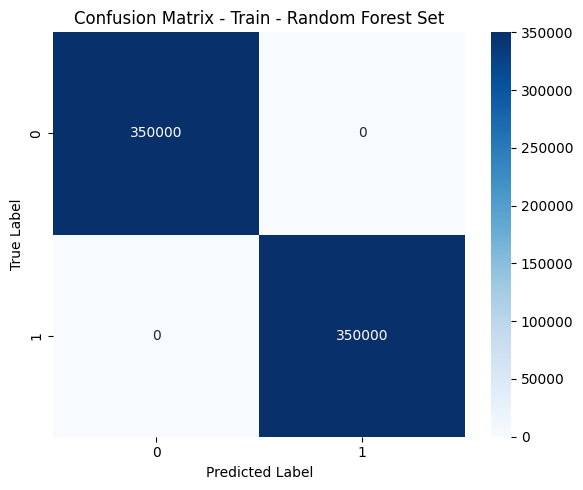


Evaluation on Validation - Random Forest Set

Performance Metrics:
  Accuracy:  0.9509
  Precision: 0.9958
  Recall:    0.0580
  F1-Score:  0.1096
  ROC-AUC:   0.6737

Classification Report:
              precision    recall  f1-score   support

           0     0.9508    1.0000    0.9748     75000
           1     0.9958    0.0580    0.1096      4120

    accuracy                         0.9509     79120
   macro avg     0.9733    0.5290    0.5422     79120
weighted avg     0.9531    0.9509    0.9297     79120



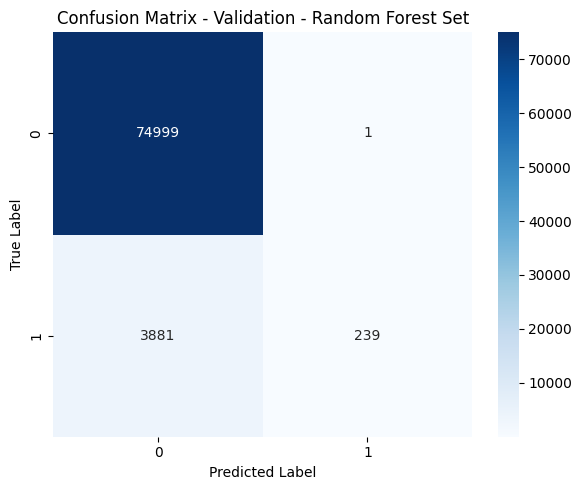


Evaluation on Test - Random Forest Set

Performance Metrics:
  Accuracy:  0.9508
  Precision: 0.9872
  Recall:    0.0563
  F1-Score:  0.1065
  ROC-AUC:   0.6673

Classification Report:
              precision    recall  f1-score   support

           0     0.9507    1.0000    0.9747     75000
           1     0.9872    0.0563    0.1065      4121

    accuracy                         0.9508     79121
   macro avg     0.9690    0.5281    0.5406     79121
weighted avg     0.9526    0.9508    0.9295     79121



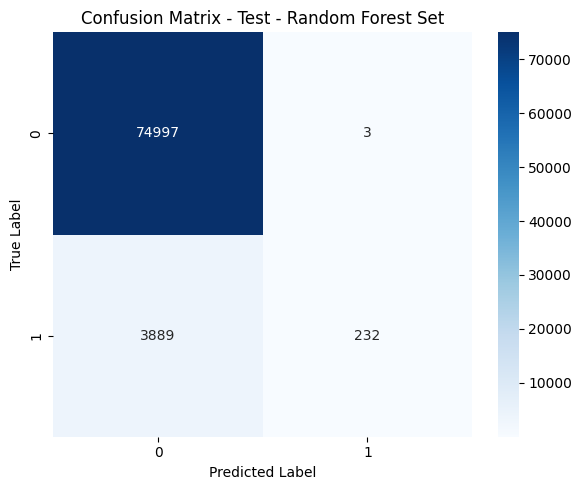

In [7]:
# Evaluate Random Forest
train_metrics_rf = evaluate_model(best_rf, X_train, y_train, dataset_name='Train - Random Forest')
val_metrics_rf = evaluate_model(best_rf, X_val, y_val, dataset_name='Validation - Random Forest')
test_metrics_rf = evaluate_model(best_rf, X_test, y_test, dataset_name='Test - Random Forest')

### 3.3 XGBoost with GridSearchCV

In [8]:
# XGBoost
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

param_grid_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 5]
}

print("XGBOOST - Grid Search (optimizing for RECALL)\n")

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_xgb.fit(X_train_gs, y_train_gs)

print(f"\nBest hyperparameters XGB: {grid_xgb.best_params_}")
print(f"Best CV score XGB (Recall): {grid_xgb.best_score_:.4f}")

# Train best model on full training set
best_xgb = grid_xgb.best_estimator_
best_xgb.fit(X_train, y_train)

print("\nXGBoost trained on full training set.")

XGBOOST - Grid Search (optimizing for RECALL)

Fitting 3 folds for each of 96 candidates, totalling 288 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_w


Evaluation on Train - XGBoost Set

Performance Metrics:
  Accuracy:  0.8853
  Precision: 0.8606
  Recall:    0.9195
  F1-Score:  0.8891
  ROC-AUC:   0.9584

Classification Report:
              precision    recall  f1-score   support

           0     0.9136    0.8510    0.8812    350000
           1     0.8606    0.9195    0.8891    350000

    accuracy                         0.8853    700000
   macro avg     0.8871    0.8853    0.8851    700000
weighted avg     0.8871    0.8853    0.8851    700000



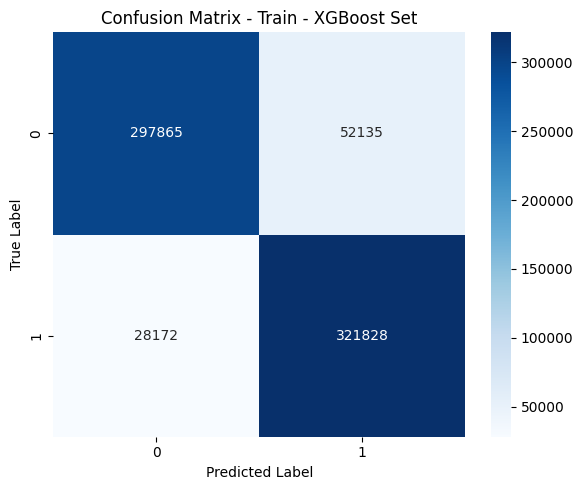


Evaluation on Validation - XGBoost Set

Performance Metrics:
  Accuracy:  0.8001
  Precision: 0.0862
  Recall:    0.2956
  F1-Score:  0.1335
  ROC-AUC:   0.5930

Classification Report:
              precision    recall  f1-score   support

           0     0.9553    0.8278    0.8870     75000
           1     0.0862    0.2956    0.1335      4120

    accuracy                         0.8001     79120
   macro avg     0.5208    0.5617    0.5102     79120
weighted avg     0.9101    0.8001    0.8478     79120



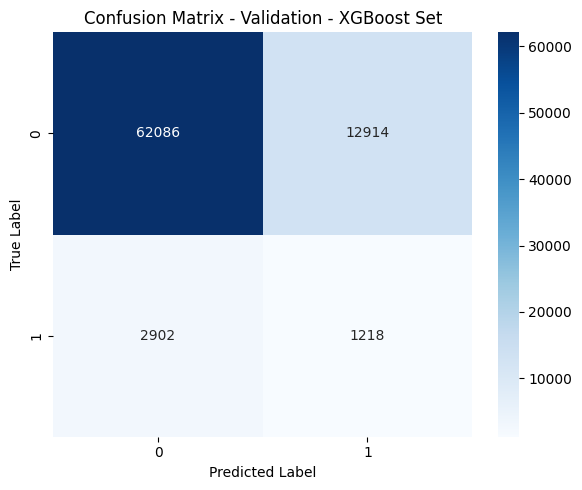


Evaluation on Test - XGBoost Set

Performance Metrics:
  Accuracy:  0.7973
  Precision: 0.0830
  Recall:    0.2878
  F1-Score:  0.1288
  ROC-AUC:   0.5915

Classification Report:
              precision    recall  f1-score   support

           0     0.9547    0.8253    0.8853     75000
           1     0.0830    0.2878    0.1288      4121

    accuracy                         0.7973     79121
   macro avg     0.5189    0.5565    0.5071     79121
weighted avg     0.9093    0.7973    0.8459     79121



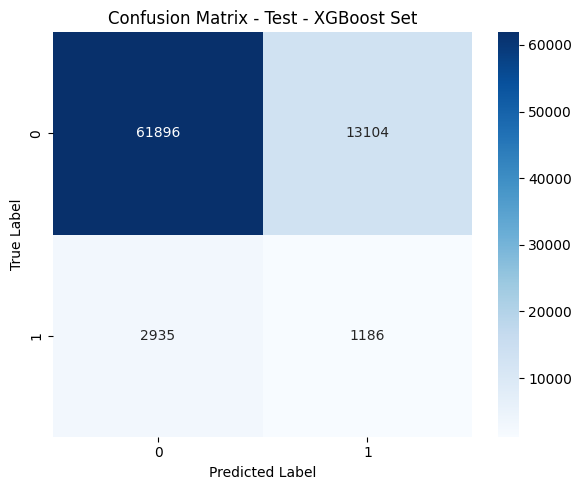

In [9]:
# Evaluate XGBoost
train_metrics_xgb = evaluate_model(best_xgb, X_train, y_train, dataset_name='Train - XGBoost')
val_metrics_xgb = evaluate_model(best_xgb, X_val, y_val, dataset_name='Validation - XGBoost')
test_metrics_xgb = evaluate_model(best_xgb, X_test, y_test, dataset_name='Test - XGBoost')

### 3.4 LightGBM with GridSearchCV

In [10]:
# LightGBM
lgbm_model = LGBMClassifier(
    objective="binary",
    metric="auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

param_grid_lgbm = {
    "n_estimators": [200, 400],
    "max_depth": [-1, 7, 10],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 63],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [20, 50],
}

print("LIGHTGBM - Grid Search (optimizing for RECALL)\n")

grid_lgbm = GridSearchCV(
    estimator=lgbm_model,
    param_grid=param_grid_lgbm,
    scoring="recall",
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_lgbm.fit(X_train_gs, y_train_gs)

print(f"\nBest hyperparameters LightGBM: {grid_lgbm.best_params_}")
print(f"Best CV score LightGBM (Recall): {grid_lgbm.best_score_:.4f}")

# Train best model on full training set
best_lgbm = grid_lgbm.best_estimator_
best_lgbm.fit(X_train, y_train)

print("\nLightGBM trained on full training set.")

LIGHTGBM - Grid Search (optimizing for RECALL)

Fitting 3 folds for each of 192 candidates, totalling 576 fits
[LightGBM] [Info] Number of positive: 66711, number of negative: 66622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4400
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500334 -> initscore=0.001335
[LightGBM] [Info] Start training from score 0.001335
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=-1, min_child_samples=20, n_estimators=200, num_leaves=31, subsample=0.8; total time=   1.0s
[LightGBM] [Info] Number of positive: 66711, number of negative: 66622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001894 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM


Evaluation on Train - LightGBM Set

Performance Metrics:
  Accuracy:  0.8901
  Precision: 0.8513
  Recall:    0.9452
  F1-Score:  0.8958
  ROC-AUC:   0.9616

Classification Report:
              precision    recall  f1-score   support

           0     0.9384    0.8349    0.8836    350000
           1     0.8513    0.9452    0.8958    350000

    accuracy                         0.8901    700000
   macro avg     0.8949    0.8901    0.8897    700000
weighted avg     0.8949    0.8901    0.8897    700000



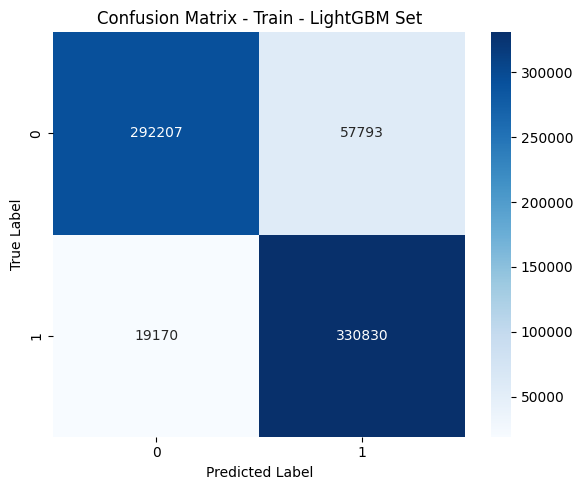


Evaluation on Validation - LightGBM Set

Performance Metrics:
  Accuracy:  0.7841
  Precision: 0.0854
  Recall:    0.3243
  F1-Score:  0.1352
  ROC-AUC:   0.6017

Classification Report:
              precision    recall  f1-score   support

           0     0.9561    0.8093    0.8766     75000
           1     0.0854    0.3243    0.1352      4120

    accuracy                         0.7841     79120
   macro avg     0.5208    0.5668    0.5059     79120
weighted avg     0.9108    0.7841    0.8380     79120



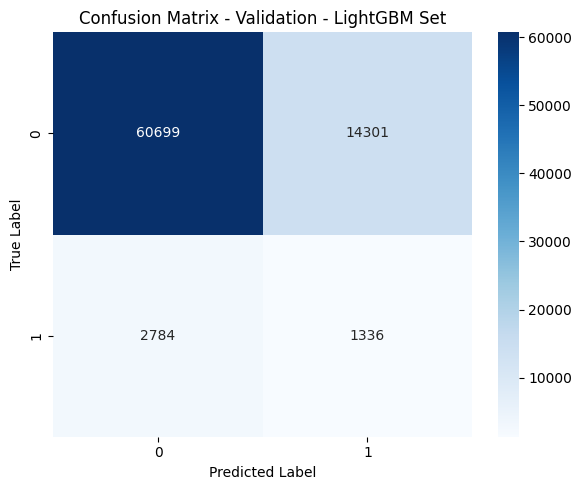


Evaluation on Test - LightGBM Set

Performance Metrics:
  Accuracy:  0.7820
  Precision: 0.0821
  Recall:    0.3128
  F1-Score:  0.1300
  ROC-AUC:   0.5991

Classification Report:
              precision    recall  f1-score   support

           0     0.9553    0.8078    0.8754     75000
           1     0.0821    0.3128    0.1300      4121

    accuracy                         0.7820     79121
   macro avg     0.5187    0.5603    0.5027     79121
weighted avg     0.9099    0.7820    0.8366     79121



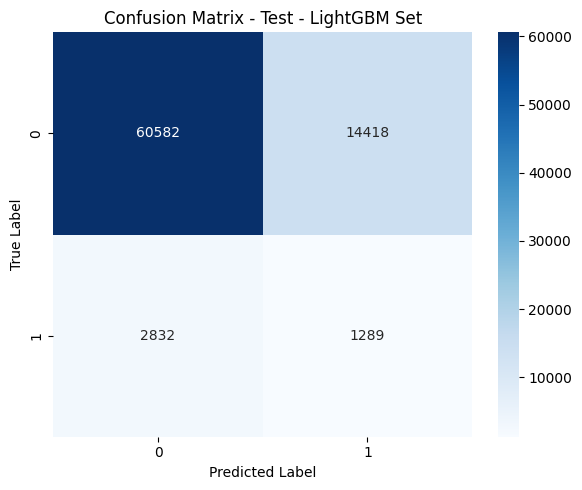

In [11]:
# Evaluate LightGBM
train_metrics_lgbm = evaluate_model(best_lgbm, X_train, y_train, dataset_name='Train - LightGBM')
val_metrics_lgbm = evaluate_model(best_lgbm, X_val, y_val, dataset_name='Validation - LightGBM')
test_metrics_lgbm = evaluate_model(best_lgbm, X_test, y_test, dataset_name='Test - LightGBM')

### 3.5 CatBoost with GridSearchCV

In [ ]:
from catboost import CatBoostClassifier, Pool

catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Recall",
    random_state=RANDOM_STATE,
    verbose=0,
    thread_count=-1
)

param_grid_catboost = {
    "iterations": [200, 400],
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "l2_leaf_reg": [1, 3, 5],
    "border_count": [32, 64],
}

train_pool = Pool(X_train_gs, y_train_gs)

print("CATBOOST - Grid Search (optimizing for RECALL)\n")

search_result = catboost_model.grid_search(
    param_grid_catboost,
    train_pool,
    cv=3,
    stratified=True,
    shuffle=True,
    partition_random_seed=RANDOM_STATE,
    verbose=False
)

best_params = search_result["params"]
best_cv_recall = max(search_result["cv_results"]["test-Recall-mean"])

print("Best hyperparameters CatBoost:", best_params)
print(f"Best CV score CatBoost (Recall): {best_cv_recall:.6f}")

best_catboost = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="Recall",
    random_state=RANDOM_STATE,
    thread_count=-1,
    verbose=0,
    **best_params
)

best_catboost.fit(X_train, y_train)
print("CatBoost trained on full training set.")

CATBOOST - Grid Search (optimizing for RECALL)


bestTest = 0.5750262329
bestIteration = 21


bestTest = 0.5672812672
bestIteration = 198


bestTest = 0.5591365612
bestIteration = 22


bestTest = 0.5737270774
bestIteration = 24


bestTest = 0.5532403937
bestIteration = 122


bestTest = 0.5716284415
bestIteration = 5


bestTest = 0.5750262329
bestIteration = 21


bestTest = 0.5958127217
bestIteration = 397


bestTest = 0.5591365612
bestIteration = 22


bestTest = 0.590466197
bestIteration = 399


bestTest = 0.5532403937
bestIteration = 122


bestTest = 0.5891170739
bestIteration = 385


bestTest = 0.5785239594
bestIteration = 184


bestTest = 0.6224454105
bestIteration = 197


bestTest = 0.5795233098
bestIteration = 197


bestTest = 0.6244441113
bestIteration = 196


bestTest = 0.5749262979
bestIteration = 199


bestTest = 0.6250936891
bestIteration = 199


bestTest = 0.6036576225
bestIteration = 399


bestTest = 0.6624194274
bestIteration = 399


bestTest = 0.6054564533
bestIteration =


Evaluation on Train - CatBoost Set

Performance Metrics:
  Accuracy:  0.7860
  Precision: 0.7597
  Recall:    0.8366
  F1-Score:  0.7963
  ROC-AUC:   0.8790

Classification Report:
              precision    recall  f1-score   support

           0     0.8182    0.7353    0.7746    350000
           1     0.7597    0.8366    0.7963    350000

    accuracy                         0.7860    700000
   macro avg     0.7889    0.7860    0.7854    700000
weighted avg     0.7889    0.7860    0.7854    700000



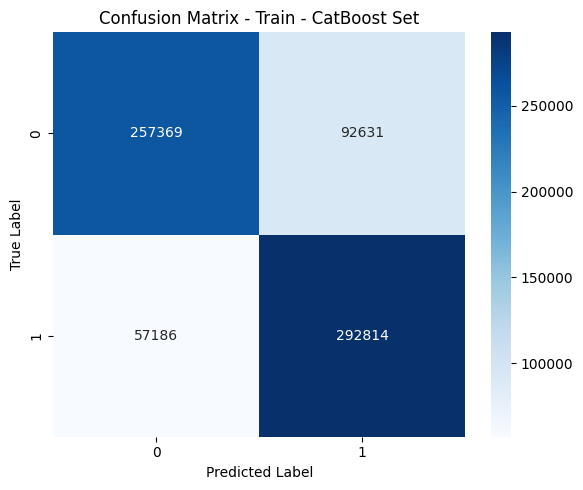


Evaluation on Validation - CatBoost Set

Performance Metrics:
  Accuracy:  0.6976
  Precision: 0.0694
  Recall:    0.3874
  F1-Score:  0.1177
  ROC-AUC:   0.5697

Classification Report:
              precision    recall  f1-score   support

           0     0.9550    0.7147    0.8176     75000
           1     0.0694    0.3874    0.1177      4120

    accuracy                         0.6976     79120
   macro avg     0.5122    0.5510    0.4676     79120
weighted avg     0.9089    0.6976    0.7811     79120



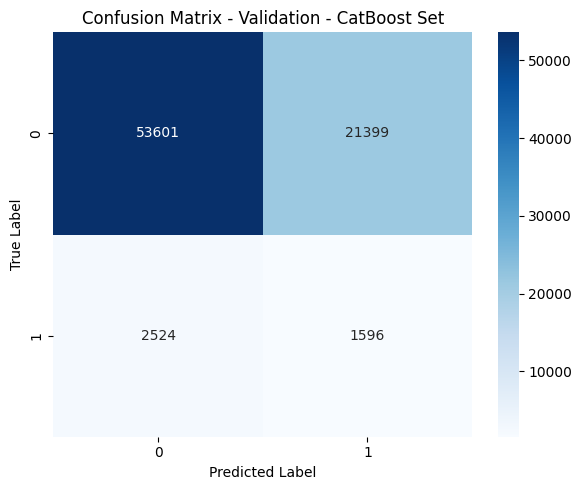


Evaluation on Test - CatBoost Set

Performance Metrics:
  Accuracy:  0.6932
  Precision: 0.0653
  Recall:    0.3671
  F1-Score:  0.1108
  ROC-AUC:   0.5596

Classification Report:
              precision    recall  f1-score   support

           0     0.9534    0.7111    0.8146     75000
           1     0.0653    0.3671    0.1108      4121

    accuracy                         0.6932     79121
   macro avg     0.5093    0.5391    0.4627     79121
weighted avg     0.9071    0.6932    0.7779     79121



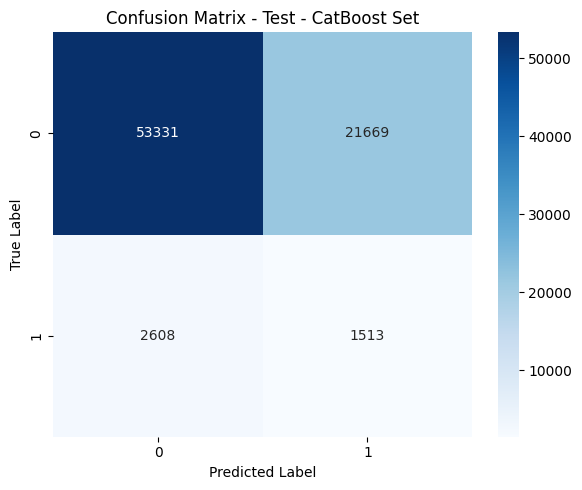

In [13]:
# Evaluate CatBoost
train_metrics_catboost = evaluate_model(best_catboost, X_train, y_train, dataset_name='Train - CatBoost')
val_metrics_catboost = evaluate_model(best_catboost, X_val, y_val, dataset_name='Validation - CatBoost')
test_metrics_catboost = evaluate_model(best_catboost, X_test, y_test, dataset_name='Test - CatBoost')

### 3.6 Compare All Models

Let's compare the performance of all four models on the test set.

MODEL COMPARISON - Test Set Performance

        Model  ROC-AUC  F1-Score  Precision   Recall
Random Forest 0.667288  0.106520   0.987234 0.056297
      XGBoost 0.591464  0.128836   0.082995 0.287794
     LightGBM 0.599092  0.130018   0.082065 0.312788
     CatBoost 0.559591  0.110830   0.065266 0.367144


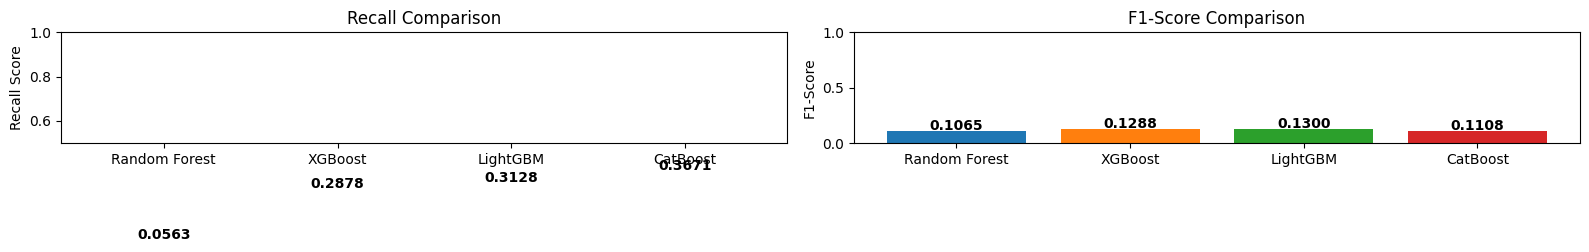


Best model selected: CatBoost
ROC-AUC: 0.5596


In [ ]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost'],
    'ROC-AUC': [
        test_metrics_rf['roc_auc'],
        test_metrics_xgb['roc_auc'],
        test_metrics_lgbm['roc_auc'],
        test_metrics_catboost['roc_auc']
    ],
    'F1-Score': [
        test_metrics_rf['f1'],
        test_metrics_xgb['f1'],
        test_metrics_lgbm['f1'],
        test_metrics_catboost['f1']
    ],
    'Precision': [
        test_metrics_rf['precision'],
        test_metrics_xgb['precision'],
        test_metrics_lgbm['precision'],
        test_metrics_catboost['precision']
    ],
    'Recall': [
        test_metrics_rf['recall'],
        test_metrics_xgb['recall'],
        test_metrics_lgbm['recall'],
        test_metrics_catboost['recall']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("MODEL COMPARISON - Test Set Performance\n")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Recall comparison
axes[0].bar(comparison_df['Model'], comparison_df['Recall'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('Recall Score')
axes[0].set_title('Recall Comparison')
axes[0].set_ylim(0.5, 1.0)
for i, v in enumerate(comparison_df['Recall']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[1].bar(comparison_df['Model'], comparison_df['F1-Score'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score Comparison')
axes[1].set_ylim(0.0, 1.0)
for i, v in enumerate(comparison_df['F1-Score']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Select best model based on Recall
best_model_idx = comparison_df['Recall'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

if best_model_name == 'Random Forest':
    model = best_rf
elif best_model_name == 'XGBoost':
    model = best_xgb
elif best_model_name == 'LightGBM':
    model = best_lgbm
else:
    model = best_catboost

print(f"\nBest model selected: {best_model_name}")
print(f"ROC-AUC: {comparison_df.loc[best_model_idx, 'ROC-AUC']:.4f}")

### 3.7 Save All Trained Models

Save all trained models to the `models/` directory for later use.

In [15]:
# Create models directory if it doesn't exist
MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

# Create a timestamp for versioning
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

print("SAVING MODELS\n")

# Save all models
models_to_save = {
    'random_forest': best_rf,
    'xgboost': best_xgb,
    'lightgbm': best_lgbm,
    'catboost': best_catboost
}

saved_models = {}

for model_name, model_obj in models_to_save.items():
    # Save with timestamp
    filename = f"{model_name}_{timestamp}.pkl"
    filepath = MODELS_DIR / filename
    
    # Save model
    joblib.dump(model_obj, filepath)
    saved_models[model_name] = str(filepath)
    print(f"Saved {model_name} to: {filepath}")
    
    # Also save as "latest" version
    latest_filename = f"{model_name}_latest.pkl"
    latest_filepath = MODELS_DIR / latest_filename
    joblib.dump(model_obj, latest_filepath)
    print(f"Also saved as: {latest_filepath}")

# Save the best model separately
best_model_filename = f"best_model_{timestamp}.pkl"
best_model_filepath = MODELS_DIR / best_model_filename
joblib.dump(model, best_model_filepath)
print(f"\nBest model ({best_model_name}) saved to: {best_model_filepath}")

# Save best model as "latest"
best_model_latest = MODELS_DIR / "best_model_latest.pkl"
joblib.dump(model, best_model_latest)
print(f"Also saved as: {best_model_latest}")

# Save model comparison results
comparison_filepath = MODELS_DIR / f"model_comparison_{timestamp}.csv"
comparison_df.to_csv(comparison_filepath, index=False)
print(f"\nModel comparison saved to: {comparison_filepath}")

# Save metadata
metadata = {
    'timestamp': timestamp,
    'best_model': best_model_name,
    'best_model_auc': float(comparison_df.loc[best_model_idx, 'ROC-AUC']),
    'models_saved': saved_models,
    'training_samples': len(X_train),
    'validation_samples': len(X_val),
    'test_samples': len(X_test),
    'features': list(X_train.columns)
}

import json
metadata_filepath = MODELS_DIR / f"training_metadata_{timestamp}.json"
with open(metadata_filepath, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Training metadata saved to: {metadata_filepath}")

print("ALL MODELS SAVED SUCCESSFULLY")

SAVING MODELS

Saved random_forest to: ../../models/random_forest_20260121_095453.pkl
Also saved as: ../../models/random_forest_latest.pkl
Saved xgboost to: ../../models/xgboost_20260121_095453.pkl
Also saved as: ../../models/xgboost_latest.pkl
Saved lightgbm to: ../../models/lightgbm_20260121_095453.pkl
Also saved as: ../../models/lightgbm_latest.pkl
Saved catboost to: ../../models/catboost_20260121_095453.pkl
Also saved as: ../../models/catboost_latest.pkl

Best model (CatBoost) saved to: ../../models/best_model_20260121_095453.pkl
Also saved as: ../../models/best_model_latest.pkl

Model comparison saved to: ../../models/model_comparison_20260121_095453.csv
Training metadata saved to: ../../models/training_metadata_20260121_095453.json
ALL MODELS SAVED SUCCESSFULLY


**Note:** You can load any saved model later using:
```python
import joblib
model = joblib.load('../../models/best_model_latest.pkl')
```

In [3]:
import joblib
model = joblib.load('../../models/best_model_latest.pkl')

## 4. SHAP Analysis

SHAP (SHapley Additive exPlanations) provides both global and local interpretability.

### 4.1 Initialize SHAP Explainer

In [ ]:
class SHAPExplainer:
    """
    Reusable SHAP explainer for fraud detection models (optimized for performance).
    """
    
    def __init__(self, model, X_background, feature_names=None, model_type='tree', 
                 max_background_samples=100):
        """
        Initialize SHAP explainer.
        
        Parameters:
        -----------
        model : trained model
            The model to explain
        X_background : pd.DataFrame or np.array
            Background data for SHAP (sample of training data)
        feature_names : list
            Names of features
        model_type : str
            Type of explainer ('tree' for tree-based models, 'kernel' for others)
        max_background_samples : int
            Maximum number of background samples (smaller = faster)
        """
        self.model = model
        self.feature_names = feature_names if feature_names is not None else X_background.columns.tolist()
        self.model_type = model_type
        
        if len(X_background) > max_background_samples:
            print(f"Sampling {max_background_samples} background samples from {len(X_background)}...")
            self.X_background = X_background.sample(n=max_background_samples, random_state=42)
        else:
            self.X_background = X_background
        
        print(f"Initializing SHAP {model_type} explainer with {len(self.X_background)} background samples...")
        
        if model_type == 'tree':
            try:
                self.explainer = shap.TreeExplainer(model)
            except Exception as e:
                print(f"Warning: TreeExplainer initialization failed: {e}")
                print("Falling back to basic TreeExplainer...")
                self.explainer = shap.TreeExplainer(model)
        elif model_type == 'kernel':
            background_sample = shap.sample(self.X_background, min(50, len(self.X_background)))
            self.explainer = shap.KernelExplainer(model.predict_proba, background_sample)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")
        
        self.shap_values = None
        self.X_explained = None
        
        print("SHAP explainer initialized!")
    
    def compute_shap_values(self, X, max_samples=100, check_additivity=False):
        """
        Compute SHAP values for a dataset.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data to explain
        max_samples : int
            Maximum number of samples to explain (RÉDUIT de None à 100 par défaut)
        check_additivity : bool
            Whether to check additivity (slower, set to False for speed)
        
        Returns:
        --------
        shap_values : array
            SHAP values
        """
        if max_samples is not None and len(X) > max_samples:
            print(f"Sampling {max_samples} samples from {len(X)} for SHAP computation...")
            X = X.sample(n=max_samples, random_state=42)
        
        print(f"Computing SHAP values for {len(X)} samples...")
        self.X_explained = X
        
        self.shap_values = self.explainer.shap_values(
            X, 
            check_additivity=check_additivity
        )
        
        # For binary classification, extract positive class SHAP values
        if isinstance(self.shap_values, list):
            self.shap_values = self.shap_values[1]
        elif isinstance(self.shap_values, np.ndarray) and self.shap_values.ndim == 3:
            print(f"Detected 3D SHAP values with shape {self.shap_values.shape}")
            print(f"Extracting positive class (index 1)...")
            self.shap_values = self.shap_values[:, :, 1]
        
        print(f"Final SHAP values shape: {self.shap_values.shape}")
        print("SHAP values computed!")
        return self.shap_values
    
    def plot_summary(self, plot_type='dot', max_display=20):
        """
        Create SHAP summary plot (global feature importance).
        
        Parameters:
        -----------
        plot_type : str
            Type of plot ('dot' or 'bar')
        max_display : int
            Maximum number of features to display
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP summary plot ({plot_type})...")
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            self.shap_values, 
            self.X_explained,
            plot_type=plot_type,
            max_display=max_display,
            show=False
        )
        plt.title(f"SHAP Feature Importance ({plot_type.capitalize()} Plot)", fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_waterfall(self, sample_idx=0):
        """
        Create SHAP waterfall plot for a single prediction (local explanation).
        
        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP waterfall plot for sample {sample_idx}...")
        
        # Create explanation object for waterfall plot
        explanation = shap.Explanation(
            values=self.shap_values[sample_idx],
            base_values=self.explainer.expected_value if not isinstance(self.explainer.expected_value, np.ndarray) else self.explainer.expected_value[1],
            data=self.X_explained.iloc[sample_idx].values,
            feature_names=self.feature_names
        )
        
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(explanation, show=False)
        plt.title(f"SHAP Waterfall Plot - Sample {sample_idx}", fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
    
    def plot_force(self, sample_idx=0):
        """
        Create SHAP force plot for a single prediction (local explanation).
        
        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        print(f"\nGenerating SHAP force plot for sample {sample_idx}...")
        
        base_value = self.explainer.expected_value
        if isinstance(base_value, np.ndarray):
            base_value = base_value[1]
        
        shap.force_plot(
            base_value,
            self.shap_values[sample_idx],
            self.X_explained.iloc[sample_idx],
            matplotlib=True,
            show=False
        )
        plt.title(f"SHAP Force Plot - Sample {sample_idx}", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    def explain_samples(self, sample_indices, y_true=None, y_pred=None):
        """
        Provide detailed explanation for multiple samples.
        
        Parameters:
        -----------
        sample_indices : list
            List of sample indices to explain
        y_true : array-like
            True labels (optional)
        y_pred : array-like
            Predicted labels (optional)
        """
        if self.shap_values is None:
            raise ValueError("SHAP values not computed yet. Call compute_shap_values() first.")
        
        for idx in sample_indices:
            print(f"\n{'='*60}")
            print(f"Explanation for Sample {idx}")
            print(f"{'='*60}")
            
            if y_true is not None:
                print(f"True Label: {y_true[idx]}")
            if y_pred is not None:
                print(f"Predicted Label: {y_pred[idx]}")
            
            print(f"\nFeature Values:")
            for feature, value in zip(self.feature_names, self.X_explained.iloc[sample_idx].values):
                shap_val = self.shap_values[idx][self.feature_names.index(feature)]
                print(f"  {feature:25s}: {value:10.4f}  (SHAP: {shap_val:+.4f})")
            
            # Show waterfall plot
            self.plot_waterfall(idx)

In [ ]:
import gc
gc.collect()

shap_explainer = SHAPExplainer(
    model=model,
    X_background=X_train,
    feature_names=None,
    model_type='tree',
    max_background_samples=50
)

shap_values = shap_explainer.compute_shap_values(
    X=X_test,
    max_samples=50,
    check_additivity=False
)

Sampling 50 background samples from 700000...
Initializing SHAP tree explainer with 50 background samples...
SHAP explainer initialized!
Sampling 50 samples from 79121 for SHAP computation...
Computing SHAP values for 50 samples...
Detected 3D SHAP values with shape (50, 24, 2)
Extracting positive class (index 1)...
Final SHAP values shape: (50, 24)
SHAP values computed!


### 4.2 Global SHAP Explanations

Global explanations show which features are most important overall for fraud detection.


Generating SHAP summary plot (dot)...


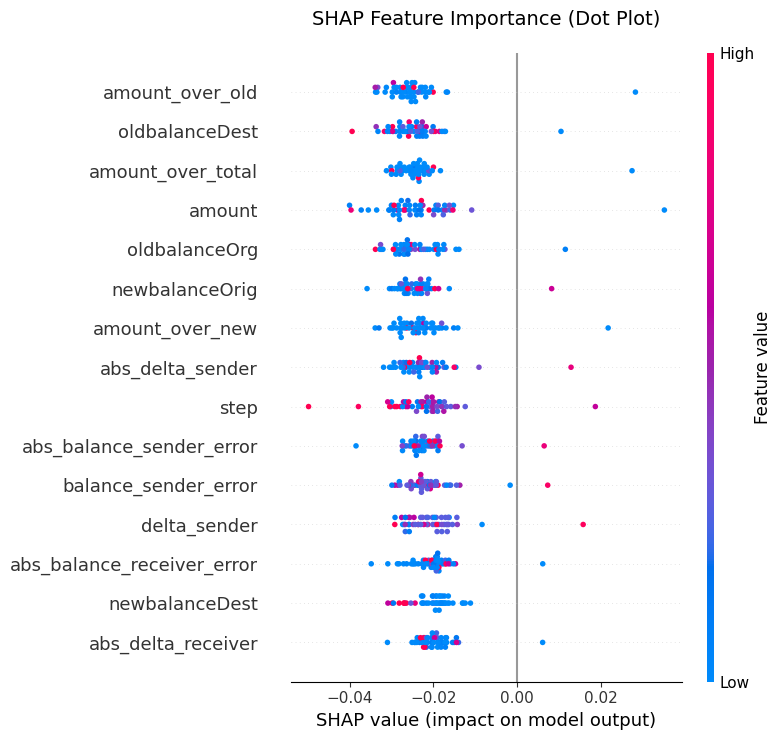

In [6]:
# SHAP summary plot (dot plot) - shows feature importance and impact
shap_explainer.plot_summary(plot_type='dot', max_display=15)


Generating SHAP summary plot (bar)...


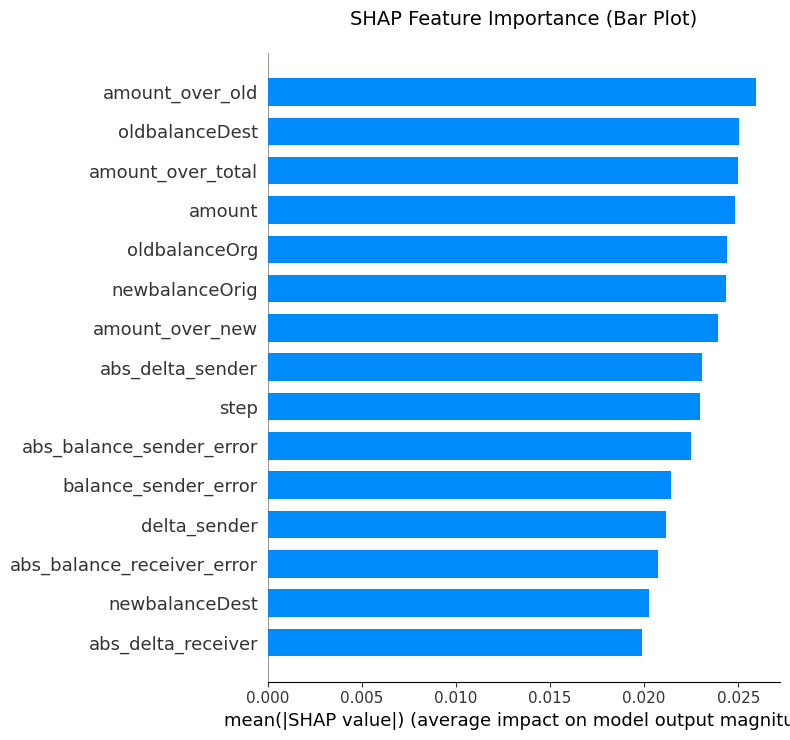

In [7]:
# SHAP summary plot (bar plot) - shows mean absolute SHAP values
shap_explainer.plot_summary(plot_type='bar', max_display=15)

### 4.3 Local SHAP Explanations

Local explanations show how features contribute to individual predictions.

In [8]:
# Get predictions on test samples
y_test_pred = model.predict(shap_explainer.X_explained)
y_test_proba = model.predict_proba(shap_explainer.X_explained)[:, 1]

# Find indices of fraud cases (true positives and false positives)
y_test_subset = y_test[shap_explainer.X_explained.index]
fraud_indices = np.where(y_test_subset == 1)[0]
predicted_fraud_indices = np.where(y_test_pred == 1)[0]

print(f"Number of actual fraud cases in sample: {len(fraud_indices)}")
print(f"Number of predicted fraud cases in sample: {len(predicted_fraud_indices)}")

# Select interesting samples to explain
if len(fraud_indices) > 0:
    sample_to_explain = fraud_indices[0]
    print(f"\nExplaining a true fraud case (index {sample_to_explain})...")
else:
    # If no fraud in sample, pick a high-confidence fraud prediction
    sample_to_explain = np.argmax(y_test_proba)
    print(f"\nExplaining highest fraud probability case (index {sample_to_explain})...")

Number of actual fraud cases in sample: 3
Number of predicted fraud cases in sample: 1

Explaining a true fraud case (index 32)...



Generating SHAP waterfall plot for sample 32...


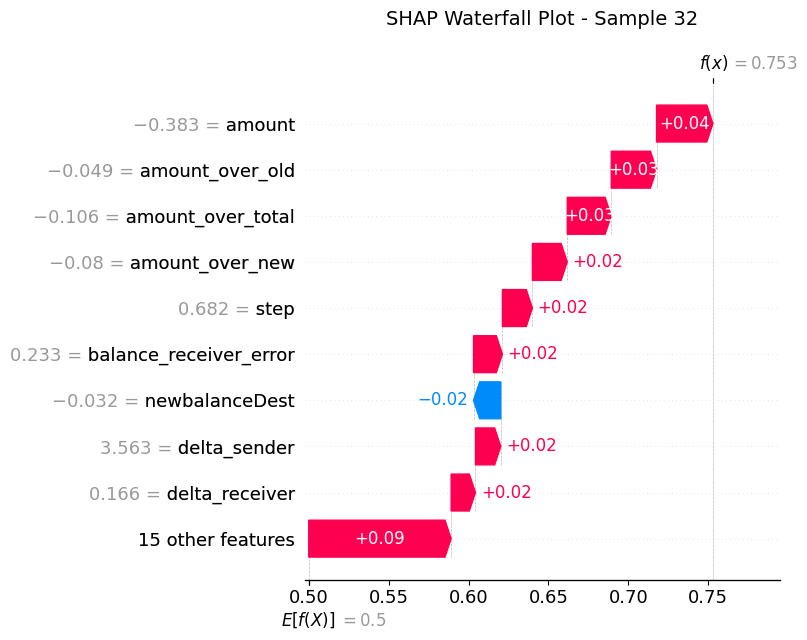

In [9]:
# Waterfall plot for a fraud case
shap_explainer.plot_waterfall(sample_to_explain)


Generating SHAP force plot for sample 32...


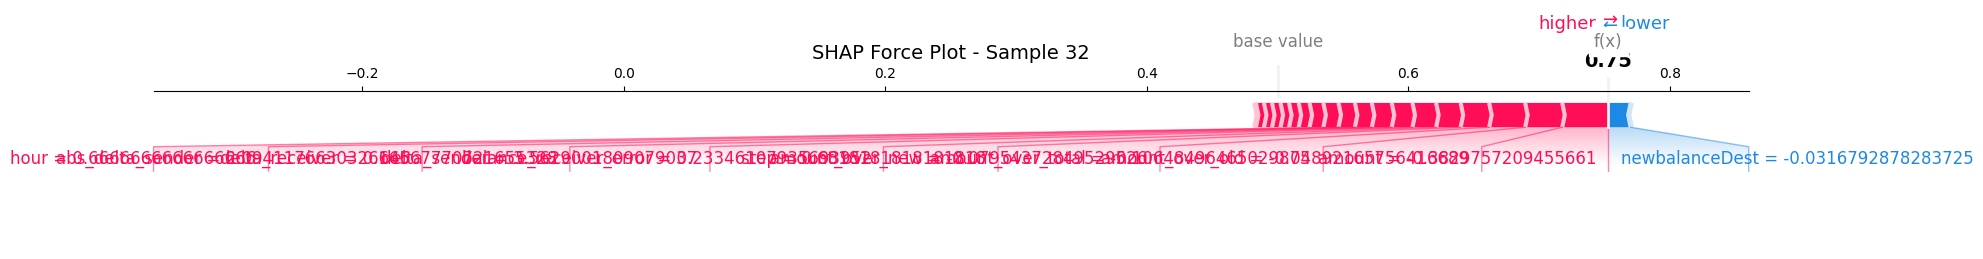

In [10]:
# Force plot for a fraud case
shap_explainer.plot_force(sample_to_explain)

In [11]:
# Explain multiple samples (e.g., first 3 fraud cases)
if len(fraud_indices) >= 3:
    samples_to_explain = fraud_indices[:3].tolist()
else:
    # Pick top 3 fraud predictions
    samples_to_explain = np.argsort(y_test_proba)[-3:].tolist()

shap_explainer.explain_samples(
    samples_to_explain, 
    y_true=y_test_subset, 
    y_pred=y_test_pred
)


Explanation for Sample 32
True Label: 1
Predicted Label: 1

Feature Values:


NameError: name 'sample_idx' is not defined

## 5. LIME Analysis

LIME (Local Interpretable Model-agnostic Explanations) provides local interpretability by approximating the model locally with an interpretable model.

### 5.1 Initialize LIME Explainer

In [12]:
class LIMEExplainer:
    """
    Reusable LIME explainer for fraud detection models.
    """
    
    def __init__(self, model, X_train, feature_names=None, class_names=None):
        """
        Initialize LIME explainer.
        
        Parameters:
        -----------
        model : trained model
            The model to explain
        X_train : pd.DataFrame or np.array
            Training data (used to understand feature distributions)
        feature_names : list
            Names of features
        class_names : list
            Names of classes
        """
        self.model = model
        self.feature_names = feature_names if feature_names is not None else X_train.columns.tolist()
        self.class_names = class_names if class_names is not None else ['Non-Fraud', 'Fraud']
        
        print(f"Initializing LIME explainer...")
        
        self.explainer = lime_tabular.LimeTabularExplainer(
            training_data=X_train.values if isinstance(X_train, pd.DataFrame) else X_train,
            feature_names=self.feature_names,
            class_names=self.class_names,
            mode='classification',
            random_state=RANDOM_STATE
        )
        
        print("LIME explainer initialized!")
    
    def explain_instance(self, X, sample_idx, num_features=10):
        """
        Explain a single prediction using LIME.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data containing the sample to explain
        sample_idx : int
            Index of the sample to explain
        num_features : int
            Number of features to show in explanation
        
        Returns:
        --------
        explanation : lime.explanation.Explanation
            LIME explanation object
        """
        print(f"\nGenerating LIME explanation for sample {sample_idx}...")
        
        if isinstance(X, pd.DataFrame):
            sample = X.iloc[sample_idx].values
        else:
            sample = X[sample_idx]
        
        explanation = self.explainer.explain_instance(
            data_row=sample,
            predict_fn=self.model.predict_proba,
            num_features=num_features
        )
        
        return explanation
    
    def plot_explanation(self, explanation, sample_idx):
        """
        Plot LIME explanation.
        
        Parameters:
        -----------
        explanation : lime.explanation.Explanation
            LIME explanation object
        sample_idx : int
            Index of the sample (for title)
        """
        # Get explanation for fraud class (class 1)
        exp_list = explanation.as_list(label=1)
        
        # Extract features and weights
        features = [item[0] for item in exp_list]
        weights = [item[1] for item in exp_list]
        
        # Create horizontal bar plot
        fig, ax = plt.subplots(figsize=(10, 6))
        
        colors = ['red' if w < 0 else 'green' for w in weights]
        y_pos = np.arange(len(features))
        
        ax.barh(y_pos, weights, color=colors, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features)
        ax.set_xlabel('Feature Weight (Impact on Fraud Prediction)', fontsize=12)
        ax.set_title(f'LIME Explanation - Sample {sample_idx}\n(Green = increases fraud probability, Red = decreases)', 
                     fontsize=14, pad=20)
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print prediction probabilities
        proba = explanation.predict_proba
        print(f"\nPrediction Probabilities:")
        for class_idx, class_name in enumerate(self.class_names):
            print(f"  {class_name}: {proba[class_idx]:.4f}")
    
    def explain_samples(self, X, sample_indices, num_features=10, y_true=None, y_pred=None):
        """
        Explain multiple samples using LIME.
        
        Parameters:
        -----------
        X : pd.DataFrame
            Data containing samples
        sample_indices : list
            List of sample indices to explain
        num_features : int
            Number of features to show in each explanation
        y_true : array-like
            True labels (optional)
        y_pred : array-like
            Predicted labels (optional)
        
        Returns:
        --------
        explanations : list
            List of LIME explanation objects
        """
        explanations = []
        
        for idx in sample_indices:
            print(f"\n{'='*60}")
            print(f"LIME Explanation for Sample {idx}")
            print(f"{'='*60}")

            true_label = int(round(y_true[idx]))
            pred_label = int(round(y_pred[idx]))
            
            if y_true is not None:
                print(f"True Label: {self.class_names[true_label]}")
            if y_pred is not None:
                print(f"Predicted Label: {self.class_names[pred_label]}")
            
            explanation = self.explain_instance(X, idx, num_features)
            self.plot_explanation(explanation, idx)
            explanations.append(explanation)
        
        return explanations

In [13]:
# Create LIME explainer
# Use training data to understand feature distributions
lime_explainer = LIMEExplainer(model, X_train)

Initializing LIME explainer...
LIME explainer initialized!


### 5.2 Local LIME Explanations

LIME provides local explanations by fitting a simple interpretable model around each prediction.

In [14]:
# Use same samples as SHAP for comparison
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
y_test_sample = y_test[X_test_sample.index]
y_pred_sample = model.predict(X_test_sample)

# Find fraud cases
fraud_indices_lime = np.where(y_test_sample == 1)[0]

if len(fraud_indices_lime) > 0:
    sample_idx = fraud_indices_lime[0]
else:
    # Pick highest fraud probability
    y_proba_sample = model.predict_proba(X_test_sample)[:, 1]
    sample_idx = np.argmax(y_proba_sample)

print(f"Selected sample index: {sample_idx}")
print(f"True label: {y_test_sample[sample_idx]}")
print(f"Predicted label: {y_pred_sample[sample_idx]}")

Selected sample index: 32
True label: 1
Predicted label: 1



Generating LIME explanation for sample 32...


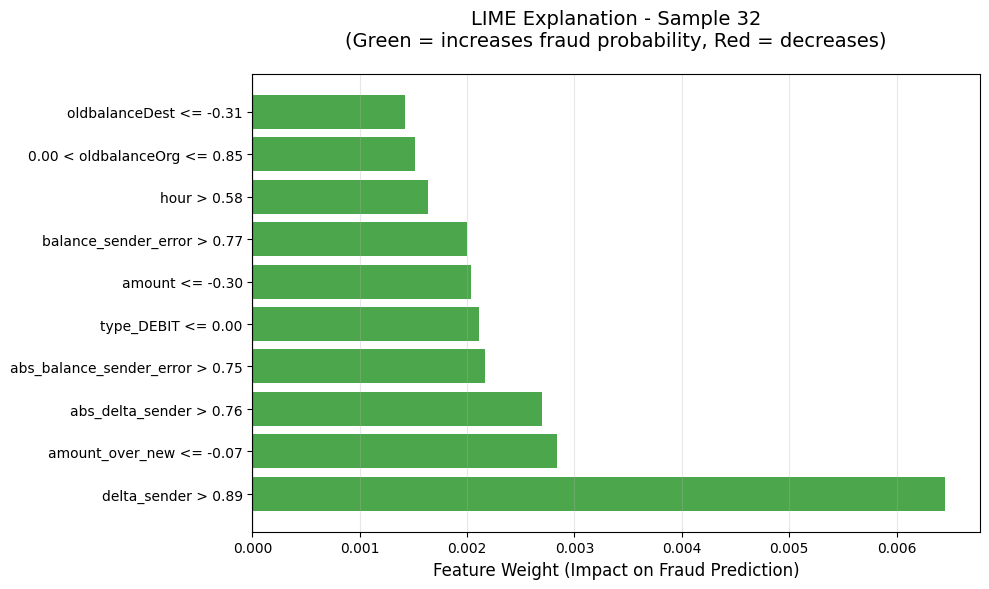


Prediction Probabilities:
  Non-Fraud: 0.2471
  Fraud: 0.7529


In [15]:
# Explain a single instance
explanation = lime_explainer.explain_instance(X_test_sample, sample_idx, num_features=10)
lime_explainer.plot_explanation(explanation, sample_idx)


LIME Explanation for Sample 32
True Label: Fraud
Predicted Label: Fraud

Generating LIME explanation for sample 32...


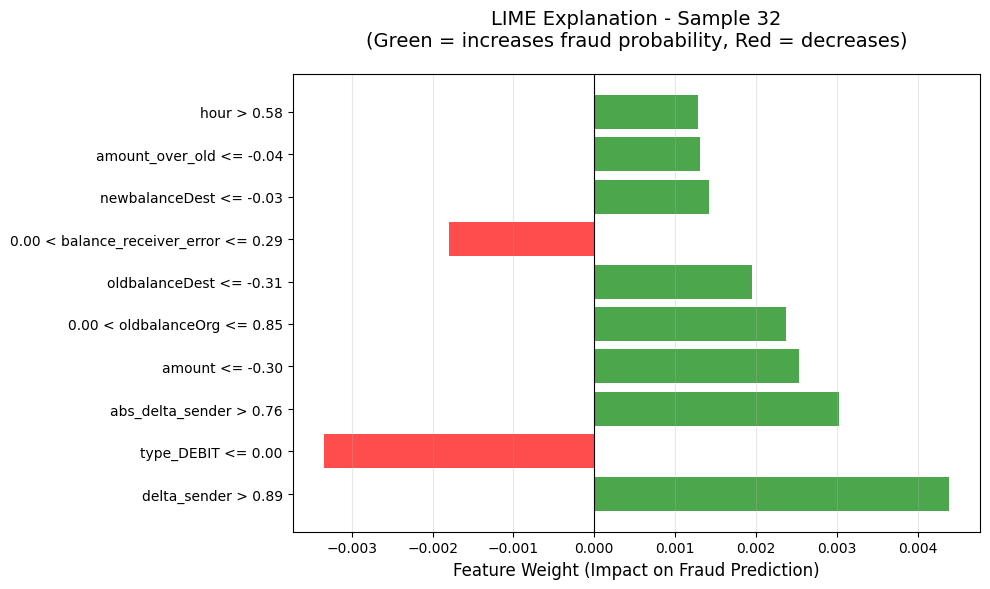


Prediction Probabilities:
  Non-Fraud: 0.2471
  Fraud: 0.7529

LIME Explanation for Sample 47
True Label: Fraud
Predicted Label: Non-Fraud

Generating LIME explanation for sample 47...


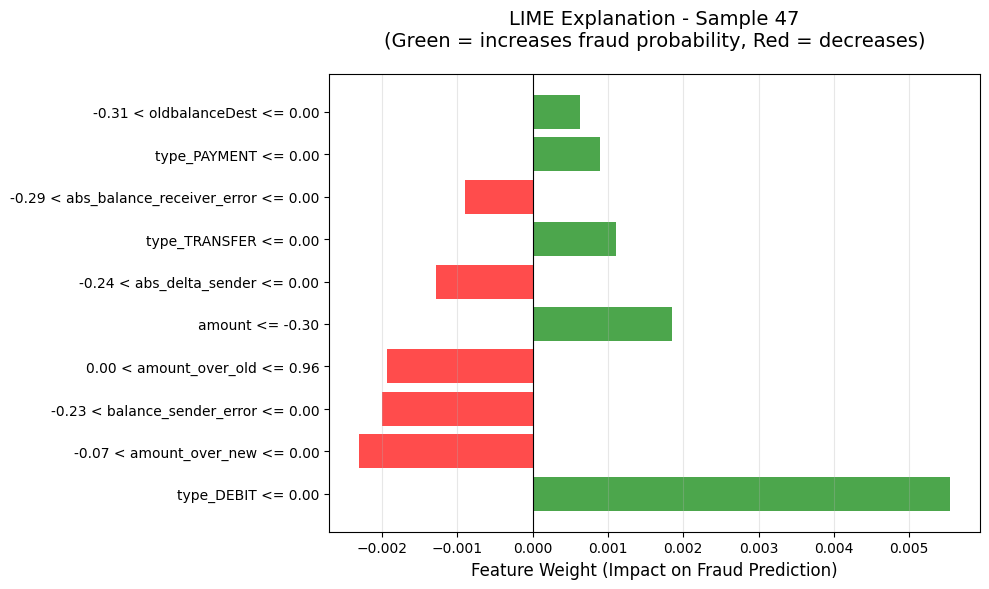


Prediction Probabilities:
  Non-Fraud: 0.9533
  Fraud: 0.0467

LIME Explanation for Sample 49
True Label: Fraud
Predicted Label: Non-Fraud

Generating LIME explanation for sample 49...


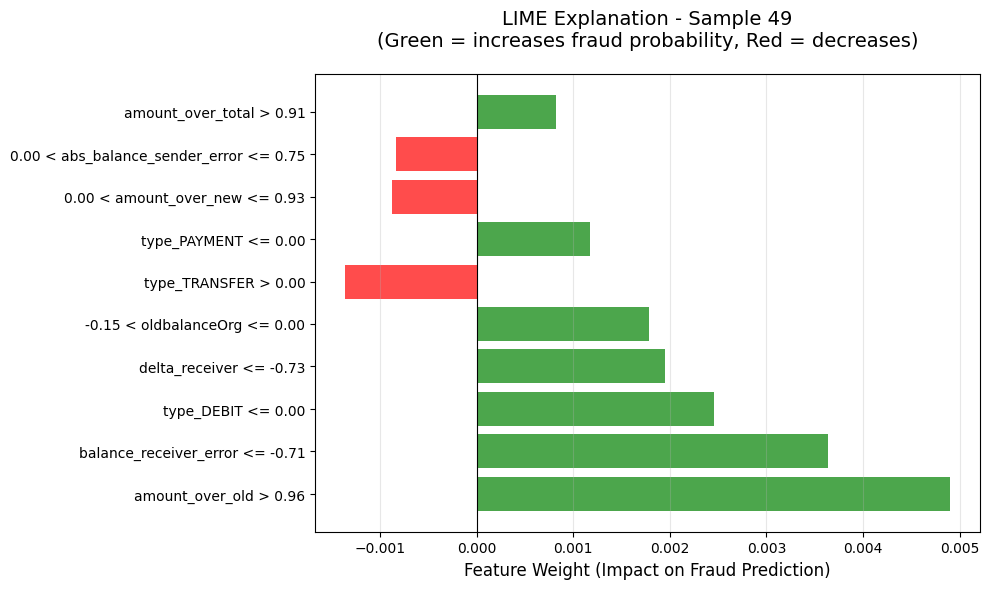


Prediction Probabilities:
  Non-Fraud: 0.8700
  Fraud: 0.1300


In [16]:
# Explain multiple samples
if len(fraud_indices_lime) >= 3:
    samples_to_explain_lime = fraud_indices_lime[:3].tolist()
else:
    y_proba_sample = model.predict_proba(X_test_sample)[:, 1]
    samples_to_explain_lime = np.argsort(y_proba_sample)[-3:].tolist()

lime_explanations = lime_explainer.explain_samples(
    X_test_sample,
    samples_to_explain_lime,
    num_features=10,
    y_true=y_test_sample,
    y_pred=y_pred_sample
)

## 6. Comparison: SHAP vs LIME

Let's compare SHAP and LIME explanations for the same samples to understand their similarities and differences.

### Key Differences:

**SHAP:**
- Based on game theory (Shapley values)
- Provides consistent and theoretically sound explanations
- TreeExplainer is very fast for tree-based models
- Global and local explanations available
- Shows actual feature contributions to prediction

**LIME:**
- Model-agnostic approach
- Approximates model locally with interpretable model
- Can be slower, especially for complex models
- Only local explanations
- May give different explanations on repeated runs (due to sampling)

### Comparison Criteria:
1. **Consistency**: Do both methods identify similar important features?
2. **Interpretability**: Which method is easier to understand for auditors?
3. **Robustness**: How stable are the explanations?
4. **Computational Cost**: Which is faster?

In [17]:
def compare_shap_lime(shap_explainer, lime_explainer, X, sample_idx, y_true=None, y_pred=None):
    """
    Compare SHAP and LIME explanations for the same sample.
    
    Parameters:
    -----------
    shap_explainer : SHAPExplainer
        SHAP explainer object
    lime_explainer : LIMEExplainer
        LIME explainer object
    X : pd.DataFrame
        Data containing the sample
    sample_idx : int
        Index of the sample to explain
    y_true : int
        True label (optional)
    y_pred : int
        Predicted label (optional)
    """
    print(f"\n{'='*80}")
    print(f"SHAP vs LIME Comparison - Sample {sample_idx}")
    print(f"{'='*80}")
    
    if y_true is not None:
        print(f"True Label: {y_true}")
    if y_pred is not None:
        print(f"Predicted Label: {y_pred}")
    
    # SHAP explanation
    print(f"\n{'-'*80}")
    print("SHAP Explanation:")
    print(f"{'-'*80}")
    shap_explainer.plot_waterfall(sample_idx)
    
    # LIME explanation
    print(f"\n{'-'*80}")
    print("LIME Explanation:")
    print(f"{'-'*80}")
    lime_explanation = lime_explainer.explain_instance(X, sample_idx, num_features=10)
    lime_explainer.plot_explanation(lime_explanation, sample_idx)
    
    # Feature importance comparison
    print(f"\n{'-'*80}")
    print("Feature Importance Comparison:")
    print(f"{'-'*80}")
    
    # Get SHAP values for this sample
    shap_values_sample = shap_explainer.shap_values[sample_idx]
    shap_importance = pd.DataFrame({
        'Feature': shap_explainer.feature_names,
        'SHAP_Value': shap_values_sample
    }).sort_values('SHAP_Value', key=abs, ascending=False).head(10)
    
    # Get LIME weights
    lime_weights = lime_explanation.as_list(label=1)
    lime_df = pd.DataFrame(lime_weights, columns=['Feature', 'LIME_Weight'])
    
    print("\nTop 10 Features by Absolute Importance:")
    print("\nSHAP:")
    for idx, row in shap_importance.iterrows():
        print(f"  {row['Feature']:25s}: {row['SHAP_Value']:+.4f}")
    
    print("\nLIME:")
    for _, row in lime_df.iterrows():
        print(f"  {row['Feature']:25s}: {row['LIME_Weight']:+.4f}")
    
    return shap_importance, lime_df

Computing SHAP values for comparison...
Sampling 50 background samples from 700000...
Initializing SHAP tree explainer with 50 background samples...
SHAP explainer initialized!
Sampling 50 samples from 79121 for SHAP computation...
Computing SHAP values for 50 samples...
Detected 3D SHAP values with shape (50, 24, 2)
Extracting positive class (index 1)...
Final SHAP values shape: (50, 24)
SHAP values computed!

SHAP vs LIME Comparison - Sample 32
True Label: 1
Predicted Label: 1

--------------------------------------------------------------------------------
SHAP Explanation:
--------------------------------------------------------------------------------

Generating SHAP waterfall plot for sample 32...


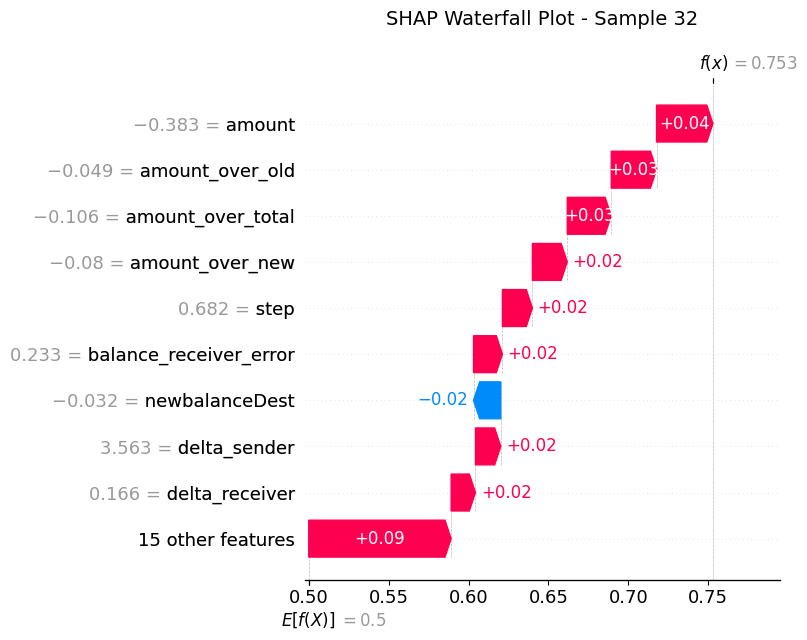


--------------------------------------------------------------------------------
LIME Explanation:
--------------------------------------------------------------------------------

Generating LIME explanation for sample 32...


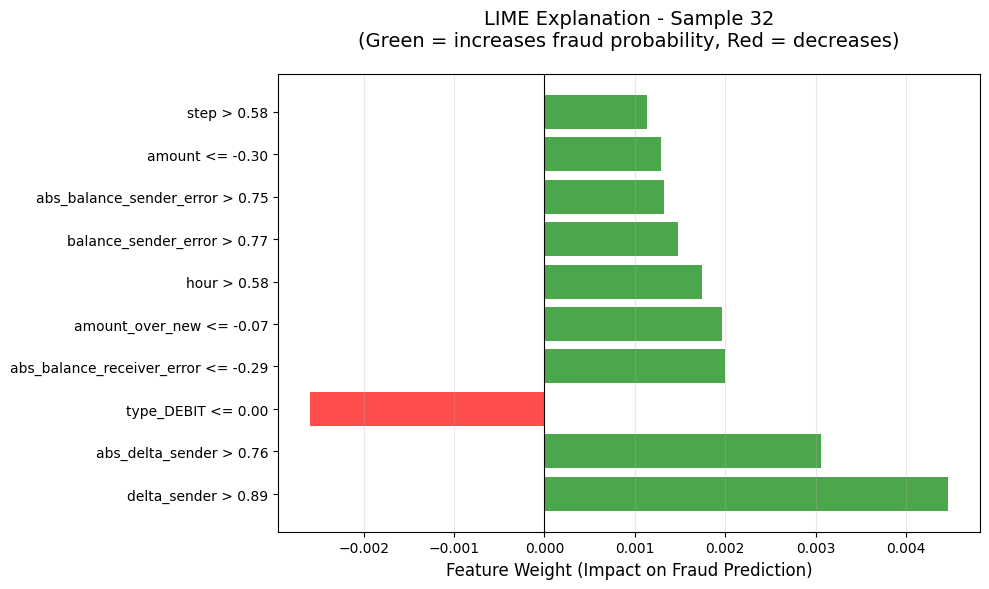


Prediction Probabilities:
  Non-Fraud: 0.2471
  Fraud: 0.7529

--------------------------------------------------------------------------------
Feature Importance Comparison:
--------------------------------------------------------------------------------

Top 10 Features by Absolute Importance:

SHAP:
  amount                   : +0.0353
  amount_over_old          : +0.0283
  amount_over_total        : +0.0275
  amount_over_new          : +0.0218
  step                     : +0.0188
  balance_receiver_error   : +0.0181
  newbalanceDest           : -0.0171
  delta_sender             : +0.0158
  delta_receiver           : +0.0152
  abs_delta_sender         : +0.0129

LIME:
  delta_sender > 0.89      : +0.0045
  abs_delta_sender > 0.76  : +0.0031
  type_DEBIT <= 0.00       : -0.0026
  abs_balance_receiver_error <= -0.29: +0.0020
  amount_over_new <= -0.07 : +0.0020
  hour > 0.58              : +0.0017
  balance_sender_error > 0.77: +0.0015
  abs_balance_sender_error > 0.75: +0.0013
  am

In [18]:
# Select a sample that's in both SHAP and LIME explained datasets
# We need to work with the intersection of indices

# For simplicity, let's re-compute SHAP on the same test sample as LIME
print("Computing SHAP values for comparison...")
shap_explainer_compare = SHAPExplainer(
    model=model,
    X_background=X_train,
    feature_names=None,
    model_type='tree',
    max_background_samples=50
)
shap_values_compare = shap_explainer_compare.compute_shap_values(
    X=X_test,
    max_samples=50,
    check_additivity=False
)

# Compare for the same sample
if len(fraud_indices_lime) > 0:
    comparison_idx = fraud_indices_lime[0]
else:
    comparison_idx = sample_idx

shap_imp, lime_imp = compare_shap_lime(
    shap_explainer_compare,
    lime_explainer,
    X_test_sample,
    comparison_idx,
    y_true=y_test_sample[comparison_idx],
    y_pred=y_pred_sample[comparison_idx]
)

## 7. Reusable XAI Pipeline

This section provides a complete reusable pipeline that can be applied to any model.

In [19]:
def complete_xai_pipeline(model, X_train, X_test, y_test, 
                         model_type='tree', 
                         num_samples_explain=5,
                         shap_background_size=1000,
                         test_sample_size=1000):
    """
    Complete XAI pipeline for fraud detection model.
    
    Parameters:
    -----------
    model : trained model
        The fraud detection model to explain
    X_train : pd.DataFrame
        Training features
    X_test : pd.DataFrame
        Test features
    y_test : array-like
        Test labels
    model_type : str
        Type of model ('tree' or 'kernel' for SHAP)
    num_samples_explain : int
        Number of individual samples to explain
    shap_background_size : int
        Size of background data for SHAP
    test_sample_size : int
        Size of test sample to explain
    
    Returns:
    --------
    results : dict
        Dictionary containing explainers and explanations
    """
    print("="*80)
    print("COMPLETE XAI PIPELINE FOR FRAUD DETECTION")
    print("="*80)
    
    # Sample test data if needed
    if len(X_test) > test_sample_size:
        test_indices = np.random.choice(len(X_test), test_sample_size, replace=False)
        X_test_sample = X_test.iloc[test_indices]
        y_test_sample = y_test[test_indices]
    else:
        X_test_sample = X_test
        y_test_sample = y_test
    
    # Get predictions
    y_pred = model.predict(X_test_sample)
    y_proba = model.predict_proba(X_test_sample)[:, 1]
    
    # ========== SHAP Analysis ==========
    print("\n" + "="*80)
    print("SHAP ANALYSIS")
    print("="*80)
    
    # Initialize SHAP
    background_data = X_train.sample(n=min(shap_background_size, len(X_train)), random_state=RANDOM_STATE)
    shap_exp = SHAPExplainer(model, background_data, model_type=model_type)
    shap_values = shap_exp.compute_shap_values(X_test_sample)
    
    # Global SHAP
    print("\n" + "-"*80)
    print("Global SHAP Explanations")
    print("-"*80)
    shap_exp.plot_summary(plot_type='dot')
    shap_exp.plot_summary(plot_type='bar')
    
    # Local SHAP
    print("\n" + "-"*80)
    print("Local SHAP Explanations")
    print("-"*80)
    
    # Find interesting samples (fraud cases and high-confidence predictions)
    fraud_indices = np.where(y_test_sample == 1)[0]
    if len(fraud_indices) >= num_samples_explain:
        samples_to_explain = fraud_indices[:num_samples_explain].tolist()
    else:
        # Combine actual frauds and top predictions
        top_preds = np.argsort(y_proba)[-(num_samples_explain - len(fraud_indices)):]
        samples_to_explain = list(fraud_indices) + list(top_preds)
    
    shap_exp.explain_samples(samples_to_explain, y_true=y_test_sample, y_pred=y_pred)
    
    # ========== LIME Analysis ==========
    print("\n" + "="*80)
    print("LIME ANALYSIS")
    print("="*80)
    
    # Initialize LIME
    lime_exp = LIMEExplainer(model, X_train)
    
    # Local LIME
    print("\n" + "-"*80)
    print("Local LIME Explanations")
    print("-"*80)
    lime_explanations = lime_exp.explain_samples(
        X_test_sample,
        samples_to_explain,
        num_features=10,
        y_true=y_test_sample,
        y_pred=y_pred
    )
    
    # ========== Comparison ==========
    print("\n" + "="*80)
    print("SHAP vs LIME COMPARISON")
    print("="*80)
    
    compare_shap_lime(
        shap_exp,
        lime_exp,
        X_test_sample,
        samples_to_explain[0],
        y_true=y_test_sample[samples_to_explain[0]],
        y_pred=y_pred[samples_to_explain[0]]
    )
    
    # ========== Results ==========
    results = {
        'shap_explainer': shap_exp,
        'lime_explainer': lime_exp,
        'shap_values': shap_values,
        'lime_explanations': lime_explanations,
        'samples_explained': samples_to_explain,
        'X_test_sample': X_test_sample,
        'y_test_sample': y_test_sample,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print("\n" + "="*80)
    print("XAI PIPELINE COMPLETED SUCCESSFULLY")
    print("="*80)
    
    return results

In [20]:
# Example: Run complete XAI pipeline on the trained model
# Uncomment to run:

# xai_results = complete_xai_pipeline(
#     model=model,
#     X_train=X_train,
#     X_test=X_test,
#     y_test=y_test,
#     model_type='tree',
#     num_samples_explain=3,
#     shap_background_size=1000,
#     test_sample_size=1000
# )